# Hutech Vehicle Dataset Exploratory Data Analysis (EDA)
### Project Goal: Finetuning YOLOv8m for Motorcycles, Cars, Trucks, and Buses

This notebook performs a detailed analysis of the Hutech Vehicle dataset located at `/media/khanhduong/1TB/master/25MCS-ML_2025-2026_S2_Final-Project/data/640 Hutech Vehicle.v2-fix-label.yolov8` and outlines how it complements the UA-DETRAC dataset to achieve robust object detection.

### Dataset Overview:
The Hutech dataset is annotated in the standard **YOLOv8 format** (pre-split into `train`, `valid`, and `test` directories). Unlike UA-DETRAC, which focuses on highway/overpass traffic and has 0 motorcycles, this dataset represents local urban traffic in Vietnam, featuring high densities of motorcycles.

---



## 1. Load Pre-computed Dataset Statistics
We load the statistical summary gathered from parsing the Hutech dataset YOLO text labels.



In [7]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

stats_path = '/home/khanhduong/.gemini/antigravity/brain/5b82f9dd-99d8-4509-8a7c-5d74b46e9633/scratch/hutech_stats.json'

with open(stats_path, 'r') as f:
    stats = json.load(f)

global_stats = stats['global']
print(f"Total images: {global_stats['total_images']}")
print(f"Total labeled files: {global_stats['total_labels']}")
print(f"Total bounding boxes: {global_stats['total_boxes']}")



Total images: 3376
Total labeled files: 3376
Total bounding boxes: 31222


## 2. Class Translation and Mapping Strategy
The Hutech dataset contains 8 classes labeled in Vietnamese. We map these to our target classes:
- Target: `motorcycle` (0), `car` (1), `truck` (2), `bus` (3)

| Vietnamese Class Name | Translation | Target YOLO Class Mapping | Target ID | Note |
| :--- | :--- | :--- | :--- | :--- |
| **`xe may`** | Motorcycle | **`motorcycle`** | `0` | Primary source for motorcycles |
| **`xe hoi`** | Car | **`car`** | `1` | Passenger vehicles |
| **`xe van`** | Van | **`car`** | `1` | Similar shape/size to cars |
| **`xe tai`** | Truck | **`truck`** | `2` | Cargo/Utility |
| **`xe container`** | Container Truck | **`truck`** | `2` | Heavy cargo |
| **`xe cuu hoa`** | Fire Truck | **`truck`** | `2` | Specialized truck |
| **`xe buyt`** | Bus | **`bus`** | `3` | Large passenger vehicle |
| **`xe dap`** | Bicycle | **N/A / Omit** | *N/A* | Can be ignored or treated as background |



In [8]:
# Vietnamese to Target Class mapping
translation_map = {
    'xe may': 'motorcycle (Class 0)',
    'xe hoi': 'car (Class 1)',
    'xe van': 'car (Class 1)',
    'xe tai': 'truck (Class 2)',
    'xe container': 'truck (Class 2)',
    'xe cuu hoa': 'truck (Class 2)',
    'xe buyt': 'bus (Class 3)',
    'xe dap': 'bicycle (Omit)'
}

# Construct dataframe for class distribution
class_counts = global_stats['class_counts']
df_classes = pd.DataFrame(list(class_counts.items()), columns=['Vietnamese Class', 'Box Count'])
df_classes['Target Mapping'] = df_classes['Vietnamese Class'].map(translation_map)
df_classes['Percentage (%)'] = (df_classes['Box Count'] / global_stats['total_boxes']) * 100
df_classes = df_classes.sort_values(by='Box Count', ascending=False)

display(df_classes)



,Vietnamese Class,Box Count,Target Mapping,Percentage (%)
3,xe may,17779,motorcycle (Class 0),56.943822
0,xe hoi,10686,car (Class 1),34.225866
1,xe tai,1163,truck (Class 2),3.724938
2,xe buyt,535,bus (Class 3),1.713535
6,xe cuu hoa,432,truck (Class 2),1.383640
5,xe van,343,car (Class 1),1.098584
4,xe dap,229,bicycle (Omit),0.733457
7,xe container,55,truck (Class 2),0.176158


### Visualizing Hutech Class Distribution
We plot the bounding box counts per class in Hutech.



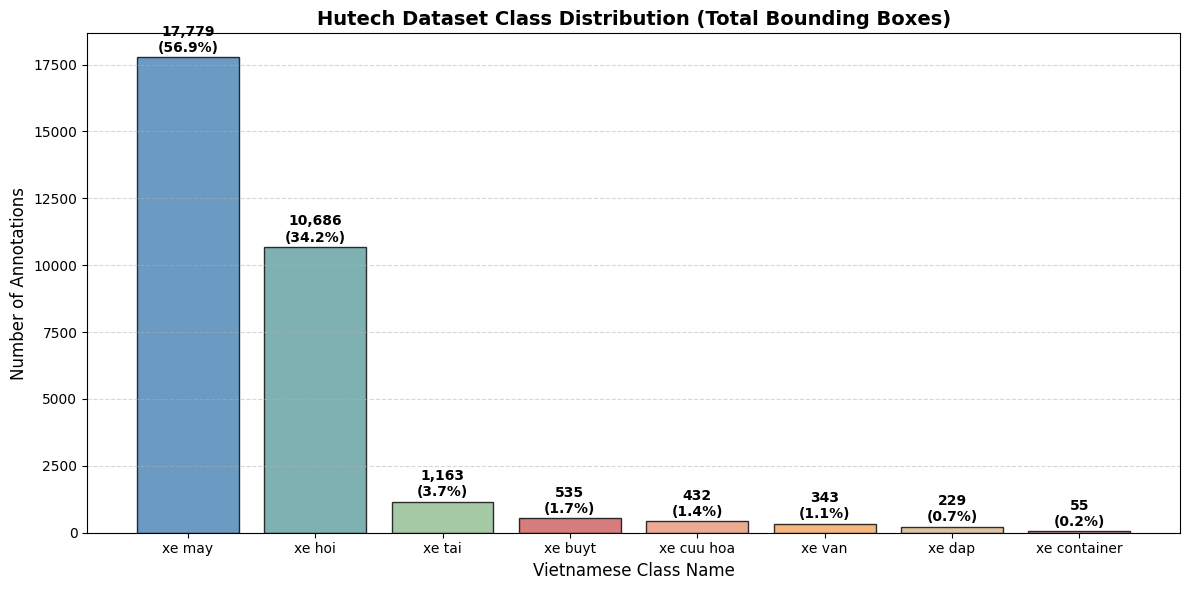

In [9]:
plt.figure(figsize=(12, 6))
colors = ['#4682B4', '#5F9EA0', '#8FBC8F', '#CD5C5C', '#E9967A', '#F4A460', '#D2B48C', '#BC8F8F']
plt.bar(df_classes['Vietnamese Class'], df_classes['Box Count'], color=colors, edgecolor='k', alpha=0.8)
plt.title('Hutech Dataset Class Distribution (Total Bounding Boxes)', fontsize=14, fontweight='bold')
plt.xlabel('Vietnamese Class Name', fontsize=12)
plt.ylabel('Number of Annotations', fontsize=12)
for i, v in enumerate(df_classes['Box Count']):
    pct = df_classes['Percentage (%)'].iloc[i]
    plt.text(i, v + 200, f"{v:,}\n({pct:.1f}%)", ha='center', fontsize=10, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()



## 3. Train / Validation / Test Split Statistics
Let's look at the distribution of images, label files, and bounding boxes across the standard splits of the Hutech dataset.



In [10]:
splits = ['train', 'valid', 'test']
split_data = []

for s in splits:
    split_data.append({
        'Split': s,
        'Images': stats[s]['num_images'],
        'Labels': stats[s]['num_labels'],
        'BBoxes': stats[s]['total_boxes'],
        'Avg BBoxes/Img': stats[s]['total_boxes'] / stats[s]['num_images'] if stats[s]['num_images'] > 0 else 0
    })

df_splits = pd.DataFrame(split_data)
display(df_splits)



,Split,Images,Labels,BBoxes,Avg BBoxes/Img
0,train,2062,2062,18687,9.062561
1,valid,574,574,5001,8.712544
2,test,740,740,7534,10.181081


### Visualizing Dataset Splits



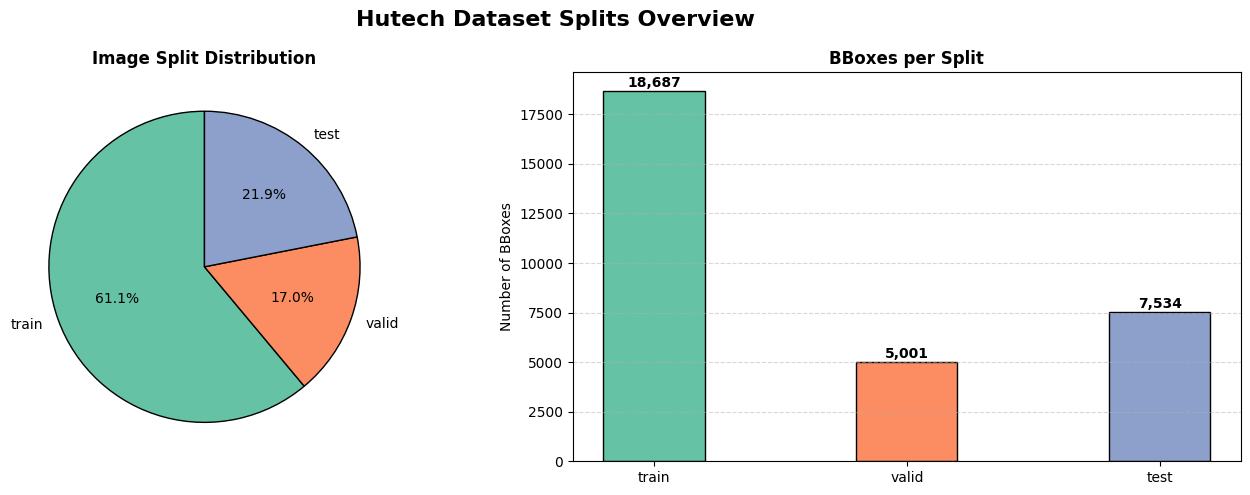

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Image distribution
axes[0].pie(df_splits['Images'], labels=df_splits['Split'], autopct='%1.1f%%', startangle=90,
           colors=['#66c2a5','#fc8d62','#8da0cb'], wedgeprops={'edgecolor': 'black', 'linewidth': 1})
axes[0].set_title('Image Split Distribution', fontsize=12, fontweight='bold')

# BBox distribution
axes[1].bar(df_splits['Split'], df_splits['BBoxes'], color=['#66c2a5','#fc8d62','#8da0cb'], edgecolor='k', width=0.4)
axes[1].set_ylabel('Number of BBoxes')
axes[1].set_title('BBoxes per Split', fontsize=12, fontweight='bold')
for i, v in enumerate(df_splits['BBoxes']):
    axes[1].text(i, v + 200, f"{v:,}", ha='center', fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Hutech Dataset Splits Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



## 4. Synergy Strategy: Combining UA-DETRAC and Hutech Dataset

Based on the quantitative properties of the UA-DETRAC and Hutech datasets, we propose a joint dataset training strategy.

### 1. Complementary Class Distributions
* **UA-DETRAC**: Captures cars (84.2%), vans (9.5%), and buses (5.6%) but has **0 motorcycles** and only **0.62%** trucks.
* **Hutech**: Labeled in Vietnam, containing **17,779 motorcycles (56.9%)** and **1,650 trucks (5.3% when combining container + tai + cuu hoa)**.
* **Synergy**: Combining them yields a balanced dataset representing highway and dense urban traffic with all target classes covered:
  - **Motorcycles**: Provided entirely by Hutech (~17.7k instances).
  - **Cars**: Shared between both (UA-DETRAC: ~560k instances, Hutech: ~11k instances).
  - **Trucks**: Merged between UA-DETRAC others (3.7k instances) and Hutech trucks/containers/fire trucks (1.6k instances) to reach ~5.3k instances.
  - **Buses**: Shared between both (UA-DETRAC: ~33.6k instances, Hutech: ~500 instances).

### 2. Formulating Synergy Hypotheses for YOLOv8m Joint Finetuning

#### Hypothesis 1: Mitigation of Catastrophic Forgetting via Joint Training
* **Observation**: If we only train on UA-DETRAC, the model forgets how to detect motorcycles. If we only train on Hutech (3.3k images), the model lacks the size and diversity of highway traffic scenes found in UA-DETRAC (82k frames).
* **Hypothesis**: *Co-training the model on a joint dataset combining Hutech and UA-DETRAC (with mapped classes) will result in a model that preserves high motorcycle detection accuracy (AP > 80% on Hutech test set) while maintaining high detection performance on highway cars and buses (AP > 90% on UA-DETRAC).*

#### Hypothesis 2: Resolution of Local Urban Domain Gaps
* **Observation**: Vietnamese urban scenes are characterized by extremely dense clustering of motorcycles, whereas UA-DETRAC scenes are structured lanes of cars.
* **Hypothesis**: *Training with a joint loss using images from both domains will regularize the feature representation in YOLOv8m's neck (FPN/PANet), improving model robustness to vehicle occlusion and density in urban highway exits.*

#### Hypothesis 3: Standardizing Aspect Ratios for Local Vehicles
* **Observation**: Bounding boxes for motorcycles (average aspect ratio ~0.65) and container trucks (aspect ratio ~1.8) require different anchor sensitivities.
* **Hypothesis**: *Recalculating the anchor boxes using K-means on the joint dataset will improve bounding box regression loss (CIoU) by aligning default priors with both long containers and tall/narrow motorcycles.*



## 5. Script to Unify and Map Classes for Joint Dataset
Below is the pipeline script to unify the Hutech dataset labels and copy them into a joint training folder alongside the converted UA-DETRAC dataset.

This script maps:
- `xe may` (5) -> `0` (motorcycle)
- `xe hoi` (4) -> `1` (car)
- `xe van` (7) -> `1` (car)
- `xe tai` (6) -> `2` (truck)
- `xe container` (1) -> `2` (truck)
- `xe cuu hoa` (2) -> `2` (truck)
- `xe buyt` (0) -> `3` (bus)
- `xe dap` (3) -> Omitted (ignored)



In [12]:
import os
import shutil
import glob
from tqdm import tqdm

def map_hutech_labels(hutech_dir, joint_output_dir):
    # Output folders
    for split in ['train', 'val']:
        os.makedirs(os.path.join(joint_output_dir, 'images', split), exist_ok=True)
        os.makedirs(os.path.join(joint_output_dir, 'labels', split), exist_ok=True)
        
    # Class map: Hutech ID -> Joint ID
    # Hutech classes: ['xe buyt':0, 'xe container':1, 'xe cuu hoa':2, 'xe dap':3, 'xe hoi':4, 'xe may':5, 'xe tai':6, 'xe van':7]
    # Joint classes: {0: 'motorcycle', 1: 'car', 2: 'truck', 3: 'bus'}
    class_map = {
        5: 0, # xe may -> motorcycle
        4: 1, # xe hoi -> car
        7: 1, # xe van -> car
        6: 2, # xe tai -> truck
        1: 2, # xe container -> truck
        2: 2, # xe cuu hoa -> truck
        0: 3  # xe buyt -> bus
        # 3 (xe dap) is omitted
    }
    
    # Hutech splits to joint splits
    split_mapping = {
        'train': 'train',
        'valid': 'val',
        'test': 'val' # Combine Hutech test and valid into validation for joint split if desired, or keep separate
    }
    
    for hutech_split, joint_split in split_mapping.items():
        images_src = os.path.join(hutech_dir, hutech_split, 'images')
        labels_src = os.path.join(hutech_dir, hutech_split, 'labels')
        
        img_paths = glob.glob(os.path.join(images_src, '*'))
        print(f"Mapping Hutech {hutech_split} -> Joint {joint_split}...")
        
        for img_path in tqdm(img_paths):
            basename = os.path.basename(img_path)
            name_no_ext, ext = os.path.splitext(basename)
            
            lbl_name = f"{name_no_ext}.txt"
            lbl_path = os.path.join(labels_src, lbl_name)
            
            # Destination paths
            dest_img_path = os.path.join(joint_output_dir, 'images', joint_split, f"hutech_{basename}")
            dest_lbl_path = os.path.join(joint_output_dir, 'labels', joint_split, f"hutech_{lbl_name}")
            
            # 1. Copy/symlink image
            if not os.path.exists(dest_img_path):
                os.symlink(img_path, dest_img_path)
                
            # 2. Map label classes and write
            if os.path.exists(lbl_path):
                mapped_lines = []
                with open(lbl_path, 'r') as f:
                    lines = f.readlines()
                for line in lines:
                    parts = line.strip().split()
                    if len(parts) < 5:
                        continue
                    class_id = int(parts[0])
                    if class_id in class_map:
                        joint_class_id = class_map[class_id]
                        mapped_lines.append(f"{joint_class_id} {parts[1]} {parts[2]} {parts[3]} {parts[4]}")
                
                with open(dest_lbl_path, 'w') as f_out:
                    f_out.write('\n'.join(mapped_lines))
                    
    print("Hutech dataset mapping and integration completed successfully!")

# To run, uncomment the lines below:
# hutech_dir = "/media/khanhduong/1TB/master/25MCS-ML_2025-2026_S2_Final-Project/data/640 Hutech Vehicle.v2-fix-label.yolov8"
# joint_output_dir = "/media/khanhduong/1TB/master/25MCS-ML_2025-2026_S2_Final-Project/data/DETRAC-YOLO" # Merge directly into same folders!
# map_hutech_labels(hutech_dir, joint_output_dir)

